# Seam Carving for Content-Aware Image Resizing

In [ ]:
import sys
from pathlib import Path

current_dir = Path.cwd()

if current_dir.name == 'notebooks':
    project_root = current_dir.parent
else:
    project_root = current_dir

if str(project_root) not in sys.path:
    sys.path.append(str(project_root))
    print(f"Project root added to path: {project_root}")

import time
import numpy as np
import cv2
import matplotlib.pyplot as plt
from numba import jit
from skimage.filters.rank import entropy as rank_entropy
from skimage.morphology import disk

%matplotlib inline

try:
    from src.utils import read_image_rgb
except ImportError as e:
    print(f"Failed to import local modules: {e}")
    print(f"Make sure the 'src' folder is in: {project_root}")

In [ ]:
input_path = project_root / 'data' / 'input' / 'test.jpg'

try:
    original_image = read_image_rgb(input_path)
    print(f"Image loaded successfully. Shape: {original_image.shape}")

except Exception as e:
    print(f"Failed to load image: {e}")

## Energy Function

Seam Carving's approach to content-aware resizing is to remove pixels in a well tought out manner.
The goal is to remove unnoticable pixels that blend with the ones surrounding them.
To compute this, we make use of a simple **energy function**:
$$
\begin{equation}
e_1(\mathbf{I}) = \left| \frac{\partial}{\partial x} \mathbf{I} \right| + \left| \frac{\partial}{\partial y} \mathbf{I} \right|
\end{equation}
$$


In [25]:
def compute_energy_map(img):
    """
    Computes the gradient energy function (e1) as defined by Avidan & Shamir.
    
    E(p) = sum_{c in {R,G,B}} ( |dIc/dx| + |dIc/dy| )
    
    Args:
        img (np.ndarray): Input image of shape (H, W, 3), dtype uint8 or float.
    
    Returns:
        np.ndarray: Energy map of shape (H, W), dtype float64.
                    Higher values indicate edges and visually important regions.
    """
    img_float = img.astype(np.float64)
    
    dx = cv2.Sobel(img_float, cv2.CV_64F, 1, 0, ksize=3)
    dy = cv2.Sobel(img_float, cv2.CV_64F, 0, 1, ksize=3)

    energy_map = np.sum(np.abs(dx) + np.abs(dy), axis=2)
    
    return energy_map

energy_map = compute_energy_map(original_image)

In [26]:
def compute_entropy_map(img, radius=5):
    """
    Computes a local entropy energy map as an alternative to the gradient-based e1.

    Entropy measures the local complexity of pixel intensities within a circular
    neighborhood, accumulated over all RGB channels.
    High entropy = high visual complexity = important regions.

    Args:
        img (np.ndarray): Input image of shape (H, W, 3), dtype uint8 or float.
        radius (int): Radius of the local neighborhood disk. Default: 5.

    Returns:
        np.ndarray: Energy map of shape (H, W), dtype float64.
    """
    d = disk(radius)
    entropy_map = np.zeros(img.shape[:2], dtype=np.float64)

    for c in range(3):
        channel = (img[:, :, c] / img[:, :, c].max() * 255).astype(np.uint8)
        entropy_map += rank_entropy(channel, d).astype(np.float64)

    return entropy_map

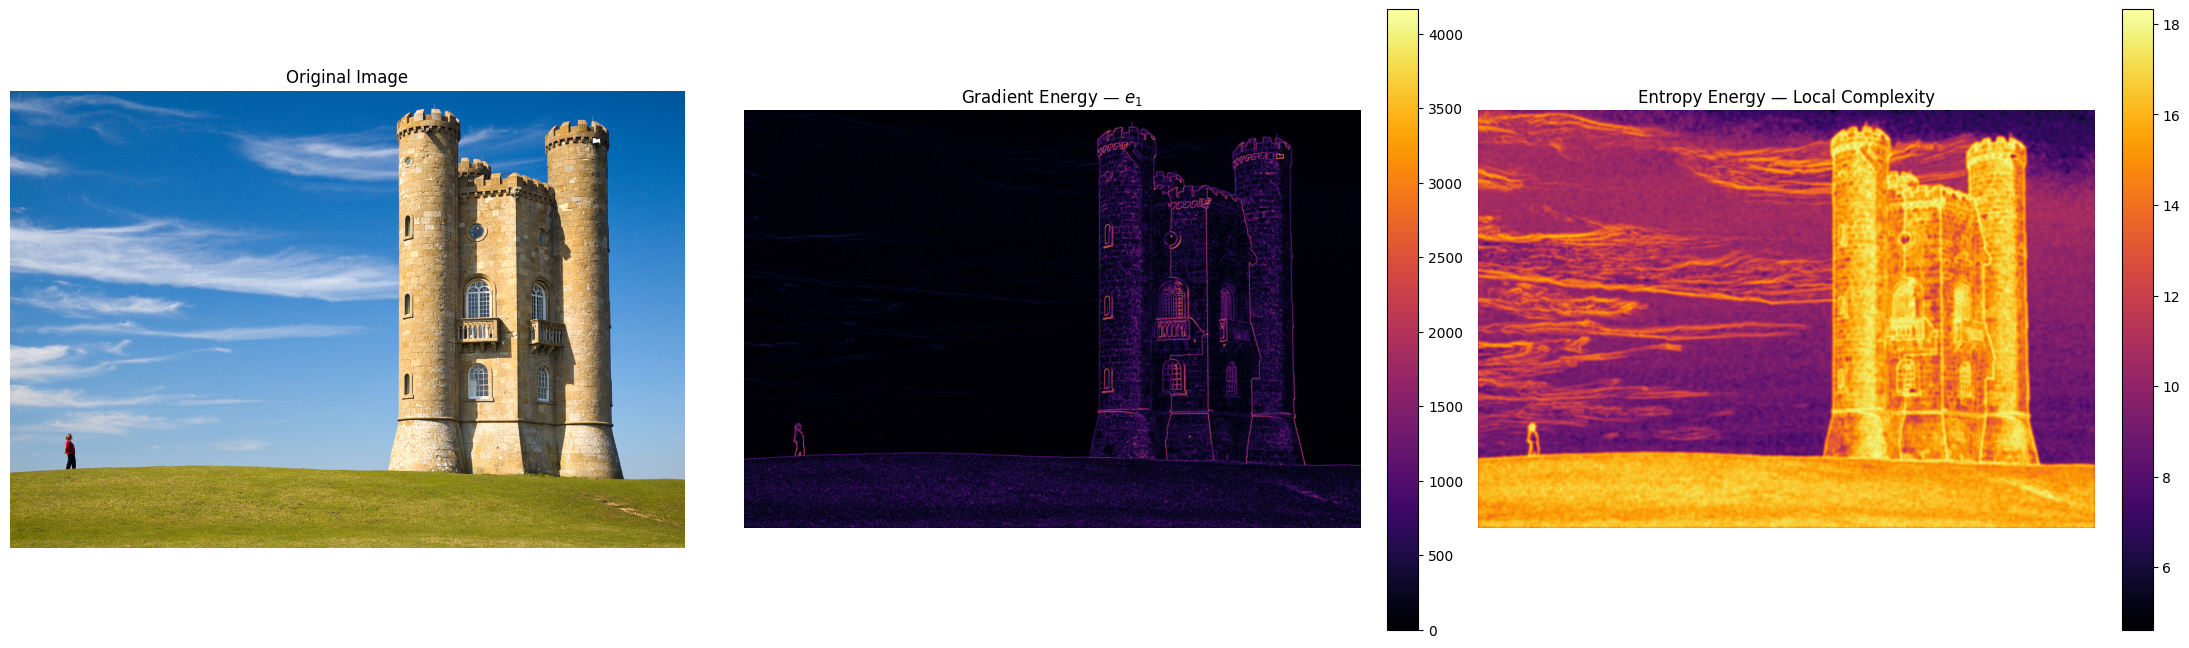

In [27]:
energy_map  = compute_energy_map(original_image)
entropy_map = compute_entropy_map(original_image)

fig, axes = plt.subplots(1, 3, figsize=(22, 8))

axes[0].imshow(original_image)
axes[0].set_title("Original Image")
axes[0].axis('off')

heatmap_e1 = axes[1].imshow(energy_map, cmap='inferno')
axes[1].set_title("Gradient Energy — $e_1$")
axes[1].axis('off')
fig.colorbar(heatmap_e1, ax=axes[1], fraction=0.046, pad=0.04)

heatmap_entropy = axes[2].imshow(entropy_map, cmap='inferno')
axes[2].set_title("Entropy Energy — Local Complexity")
axes[2].axis('off')
fig.colorbar(heatmap_entropy, ax=axes[2], fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()

## Optimal Seam Finding

In [ ]:
@jit(nopython=True)
def compute_cumulative_map(energy):
    """
    Computes the cumulative minimum energy map using Dynamic Programming.
    
    Args:
        energy (np.ndarray): Energy map of shape (H, W), dtype float64.
    Returns:
        np.ndarray: Cumulative cost matrix M of shape (H, W), dtype float64.
    """
    rows, cols = energy.shape
    
    M = energy.copy()

    for r in range(1, rows):
        for c in range(cols):
            
            if c == 0:
                min_prev = min(M[r-1, c], M[r-1, c+1])
            
            elif c == cols - 1:
                min_prev = min(M[r-1, c-1], M[r-1, c])
            
            else:
                min_prev = min(M[r-1, c-1], M[r-1, c], M[r-1, c+1])
            
            M[r, c] += min_prev
            
    return M

cost_matrix = compute_cumulative_map(energy_map)
print(f"Cumulative Map computed. Shape: {cost_matrix.shape}")

In [ ]:
plt.figure(figsize=(10, 8))

plt.imshow(cost_matrix, cmap='viridis')
# Lighter = Higher Cumulative Cost  
plt.title("Cumulative Cost Matrix (M)")
plt.colorbar(label="Total Path Cost")
plt.axis('off')
plt.show()

In [ ]:
@jit(nopython=True)
def find_vertical_seam(cost_matrix):
    """
    Recovers the optimal vertical seam via backtracking on the cumulative cost matrix.

    Starting from the minimum-cost pixel in the last row, we trace upward
    row by row, always stepping to the cheapest of the (up to 3) neighbors
    in the row above — mirroring the connectivity used during DP construction.

    Args:
        cost_matrix (np.ndarray): Cumulative cost matrix M of shape (H, W).

    Returns:
        seam (np.ndarray): Array of shape (H,) with the column index to remove per row.
    """
    rows, cols = cost_matrix.shape
    seam = np.zeros(rows, dtype=np.int32)
    current_col = np.argmin(cost_matrix[-1])
    seam[-1] = current_col

    for r in range(rows - 2, -1, -1):
        start_c = max(0, current_col - 1)
        end_c   = min(cols - 1, current_col + 1)

        # Manual argmin over the (up to 3) neighbors — required by nopython=True
        min_val = cost_matrix[r, start_c]
        current_col = start_c
        for c in range(start_c + 1, end_c + 1):
            if cost_matrix[r, c] < min_val:
                min_val = cost_matrix[r, c]
                current_col = c

        seam[r] = current_col
    return seam

seam = find_vertical_seam(cost_matrix)
print(f"Seam found. Length: {len(seam)}")
print(f"Seam starts at col {seam[0]} and ends at col {seam[-1]}")

In [ ]:
img_with_seam = original_image.copy()

for r in range(img_with_seam.shape[0]):
    c = seam[r]
    
    if 0 <= c < img_with_seam.shape[1]:
        img_with_seam[r, c] = [255, 0, 0]

plt.figure(figsize=(10, 8))
plt.imshow(img_with_seam)
plt.title("Original Image with Optimal Seam (Red)")
plt.axis('off')
plt.show()

In [ ]:
def remove_vertical_seam(img, seam):
    """
    Removes the vertical seam using vectorized boolean masking.
    
    Args:
        img: Input image (H, W, 3).
        seam: Seam path (H,) containing column indices to remove.
        
    Returns:
        output: New image with shape (H, W-1, 3).
    """
    rows, cols, channels = img.shape
    
    mask = np.ones((rows, cols), dtype=bool)
    
    mask[np.arange(rows), seam] = False

    output = img[mask].reshape(rows, cols - 1, channels)
    
    return output

print(f"Original shape: {original_image.shape}")
carved_image = remove_vertical_seam(original_image, seam)
print(f"Carved shape:   {carved_image.shape}")

In [ ]:
fig, (ax_original, ax_carved) = plt.subplots(1, 2, figsize=(15, 8))

ax_original.imshow(original_image)
ax_original.set_title(f"Original: {original_image.shape[1]}px width")
ax_original.axis('off')

ax_carved.imshow(carved_image)
ax_carved.set_title(f"Carved: {carved_image.shape[1]}px width")
ax_carved.axis('off')

plt.show()

## Seam Removal

In [ ]:
def resize_image_seam_carving(img, num_seams_to_remove, return_seams=False, verbose=True):
    """
    Resizes the image by removing the specified number of vertical seams.
    
    Args:
        img (np.ndarray): Input image (H, W, 3).
        num_seams_to_remove (int): Number of vertical seams to remove.
        return_seams (bool): If True, also returns seam paths mapped to
                             original image coordinates. Default: False.
        verbose (bool): If True, prints progress and timing. Default: True.
    
    Returns:
        img_processed (np.ndarray): Resized image of shape (H, W - num_seams, 3).
        seams_original (list of np.ndarray): Only returned if return_seams=True.
                        Each element is a (H,) array of column indices in the
                        original image coordinate space.
    """
    rows, cols = img.shape[:2]

    if num_seams_to_remove >= cols:
        raise ValueError(f"Cannot remove {num_seams_to_remove} seams from an image with width {cols}.")

    img_processed = img.copy()

    if return_seams:
        col_map = np.tile(np.arange(cols), (rows, 1))
        seams_original = []

    if verbose:
        print(f"Starting Seam Carving. Target: remove {num_seams_to_remove} seams.")
    start_time = time.time()

    for i in range(num_seams_to_remove):
        energy         = compute_energy_map(img_processed)
        cumulative_map = compute_cumulative_map(energy)
        seam           = find_vertical_seam(cumulative_map)

        if return_seams:
            seams_original.append(col_map[np.arange(rows), seam])
            mask    = np.ones(col_map.shape, dtype=bool)
            mask[np.arange(rows), seam] = False
            col_map = col_map[mask].reshape(rows, -1)

        img_processed = remove_vertical_seam(img_processed, seam)

        if verbose and (i + 1) % 10 == 0:
            print(f"  Progress: removed {i + 1}/{num_seams_to_remove} seams", end="\r")

    if verbose:
        total_time = time.time() - start_time
        print(f"\nCompleted in {total_time:.2f} seconds.")
        print(f"Final shape: {img_processed.shape}")

    return (img_processed, seams_original) if return_seams else img_processed

In [ ]:
def draw_seams(img, seams, color=(255, 0, 0)):
    """Draws collected seams on the original image. Fully vectorized."""
    viz = img.copy()
    rows = np.arange(img.shape[0])
    for seam in seams:
        viz[rows, seam] = color
    return viz

In [ ]:
PIXELS_TO_REMOVE_X = 400
img_resized_x, seams = resize_image_seam_carving(
    original_image, PIXELS_TO_REMOVE_X, return_seams=True
)

fig, axes = plt.subplots(1, 3, figsize=(22, 8))

axes[0].imshow(original_image)
axes[0].set_title(f"Original\n{original_image.shape[1]}px width")
axes[0].axis('off')

axes[1].imshow(draw_seams(original_image, seams))
axes[1].set_title(f"{PIXELS_TO_REMOVE_X} optimal seams\n(red = removed paths)")
axes[1].axis('off')

axes[2].imshow(img_resized_x)
axes[2].set_title(f"Seam Carved (-{PIXELS_TO_REMOVE_X}px)\n{img_resized_x.shape[1]}px width")
axes[2].axis('off')

plt.tight_layout()
plt.show()

In [ ]:
img_standard_resize = cv2.resize(original_image, dsize=(original_image.shape[1] - PIXELS_TO_REMOVE_X, original_image.shape[0]), interpolation=cv2.INTER_AREA)

fig, (ax_seam_resize, ax_standard_resize) = plt.subplots(1, 2, figsize=(15, 8))

ax_seam_resize.imshow(img_resized_x)
ax_seam_resize.set_title("Resize via seam carving")
ax_seam_resize.axis("off")


ax_standard_resize.imshow(img_standard_resize)
ax_standard_resize.set_title("Resize via standard resizing")
ax_standard_resize.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
def resize_horizontal(img, num_seams):
    """
    Removes horizontal seams by rotating the image, applying vertical removal, 
    and rotating back.
    
    Args:
        img: Input image (H, W, 3).
        num_seams: Number of rows (pixels height) to remove.
        
    Returns:
        output: Resized image (H-num_seams, W, 3).
    """
    print(f"Horizontal resize (Target: -{num_seams} height)")
    
    img_transposed = np.transpose(img, (1, 0, 2))
    
    img_processed_t = resize_image_seam_carving(img_transposed, num_seams, verbose=True)
    
    output = np.transpose(img_processed_t, (1, 0, 2))
    
    return output

In [ ]:
PIXELS_TO_REMOVE_Y = 100

img_resized_y = resize_horizontal(original_image, PIXELS_TO_REMOVE_Y)

fig, (ax_original, ax_carved) = plt.subplots(1, 2, figsize=(15, 8))

ax_original.imshow(original_image)
ax_original.set_title(f"Original Image\n{original_image.shape}")

ax_carved.imshow(img_resized_y)
ax_carved.set_title(f"Seam Carved Image (-{PIXELS_TO_REMOVE_Y}px Height)\n{img_resized_y.shape}")

plt.show()

## Content-aware enlargement

In [ ]:
def insert_vertical_seam(img, seam):
    """
    Inserts a vertical seam by averaging each seam pixel with its left and right neighbors.
    Fully vectorized — no explicit row loop.

    Args:
        img (np.ndarray): Input image (H, W, 3).
        seam (np.ndarray): Array of shape (H,) with column indices to duplicate.

    Returns:
        np.ndarray: Image of shape (H, W+1, 3).
    """
    rows, cols, channels = img.shape
    output = np.zeros((rows, cols + 1, channels), dtype=img.dtype)

    row_idx = np.arange(rows)
    col_idx = np.arange(cols)

    output_cols = np.where(col_idx[np.newaxis, :] <= seam[:, np.newaxis],
                           col_idx[np.newaxis, :],
                           col_idx[np.newaxis, :] + 1)

    output[row_idx[:, np.newaxis], output_cols] = img

    left  = np.maximum(seam - 1, 0)
    right = np.minimum(seam + 1, cols - 1)

    output[row_idx, seam + 1] = (
        (img[row_idx, left].astype(np.float64) +
        img[row_idx, seam].astype(np.float64) +
        img[row_idx, right].astype(np.float64)) / 3
    ).astype(img.dtype)

    return output

In [ ]:
def enlarge_image_seam_carving(img, num_seams):
    """
    Enlarges the image by inserting num_seams vertical seams in a content-aware manner.

    All k seams are found on the original image first, then inserted left-to-right.
    Each new column is synthesized by averaging the seam pixel with its left and right neighbors.

    Args:
        img (np.ndarray): Input image of shape (H, W, 3).
        num_seams (int): Number of seams to insert.

    Returns:
        np.ndarray: Enlarged image of shape (H, W + num_seams, 3).
    """
    start_time = time.time()

    print(f"Finding {num_seams} optimal seams.")
    _, seams = resize_image_seam_carving(img, num_seams, return_seams=True, verbose=False)
    print(f"Found {num_seams} optimal seams. Starting insertion.")

    seams_sorted = sorted(seams, key=lambda s: np.median(s))

    output = img.copy()
    for i, seam in enumerate(seams_sorted):
        output = insert_vertical_seam(output, seam + i)
        if (i + 1) % 10 == 0:
            print(f"  Progress: inserted {i + 1}/{num_seams} seams", end="\r")

    total_time = time.time() - start_time
    print(f"\nCompleted in {total_time:.2f} seconds.")
    print(f"Final shape: {output.shape}")

    return output

In [ ]:
PIXELS_TO_ADD_X = 200
img_enlarged = enlarge_image_seam_carving(original_image, PIXELS_TO_ADD_X)

fig, (ax_original, ax_enlarged) = plt.subplots(1, 2, figsize=(18, 8))

ax_original.imshow(original_image)
ax_original.set_title(f"Original\n{original_image.shape[1]}px width")
ax_original.axis('off')

ax_enlarged.imshow(img_enlarged)
ax_enlarged.set_title(f"Enlarged (+{PIXELS_TO_ADD_X}px)\n{img_enlarged.shape[1]}px width")
ax_enlarged.axis('off')

plt.tight_layout()
plt.show()

In [ ]:
def enlarge_horizontal(img, num_seams):
    """
    Enlarges the image vertically by inserting horizontal seams.
    Uses the transpose trick, mirroring resize_horizontal.

    Args:
        img (np.ndarray): Input image (H, W, 3).
        num_seams (int): Number of seams to insert (pixels added to height).

    Returns:
        np.ndarray: Enlarged image of shape (H + num_seams, W, 3).
    """
    img_transposed = np.transpose(img, (1, 0, 2))
    img_enlarged_t = enlarge_image_seam_carving(img_transposed, num_seams)
    return np.transpose(img_enlarged_t, (1, 0, 2))

In [ ]:
PIXELS_TO_ADD_Y = 100
img_enlarged_y = enlarge_horizontal(original_image, PIXELS_TO_ADD_Y)

fig, (ax_original, ax_enlarged) = plt.subplots(1, 2, figsize=(15, 8))

ax_original.imshow(original_image)
ax_original.set_title(f"Original\n{original_image.shape[0]}px height")
ax_original.axis('off')

ax_enlarged.imshow(img_enlarged_y)
ax_enlarged.set_title(f"Enlarged (+{PIXELS_TO_ADD_Y}px)\n{img_enlarged_y.shape[0]}px height")
ax_enlarged.axis('off')

plt.tight_layout()
plt.show()

## Object removal

The seam carving framework extends naturally to object removal by exploiting the energy function.
Given a user-defined region to remove, pixels inside it are assigned a large negative energy value:

$$e(p) = -10^9 \quad \forall p \in \text{region}$$

A large negative constant is used in place of $-\infty$ for numerical compatibility.

This forces the DP to route seams through the masked region. No structural changes to the algorithm are needed.
Seams are removed iteratively until the entire bounding box width is eliminated.
The mask is updated at each step to stay aligned with the shrinking image coordinates.

In [ ]:
def remove_object(img, bbox):
    """
    Removes a rectangular region by forcing seams through it via negative energy.

    The masked pixels are assigned a large negative energy value, making them
    the preferred path for the seam carving algorithm. Seams are removed until
    the entire bounding box width is eliminated.

    Args:
        img (np.ndarray): Input image (H, W, 3).
        bbox (tuple): Region to remove as (x1, y1, x2, y2) in pixel coordinates.

    Returns:
        np.ndarray: Image with the object removed, shape (H, W - bbox_width, 3).
    """
    x1, y1, x2, y2 = bbox
    num_seams = x2 - x1

    img_processed = img.copy()
    current_mask  = np.zeros(img.shape[:2], dtype=bool)
    current_mask[y1:y2, x1:x2] = True

    print(f"Object removal: {num_seams} seams to remove.")
    start_time = time.time()

    for i in range(num_seams):
        energy = compute_energy_map(img_processed)
        energy[current_mask] = -1e9

        M    = compute_cumulative_map(energy)
        seam = find_vertical_seam(M)

        # Update mask to stay aligned with the shrinking image
        mask_remove = np.ones(current_mask.shape, dtype=bool)
        mask_remove[np.arange(img_processed.shape[0]), seam] = False
        current_mask  = current_mask[mask_remove].reshape(img_processed.shape[0], -1)

        img_processed = remove_vertical_seam(img_processed, seam)

        if (i + 1) % 10 == 0:
            print(f"  Progress: removed {i + 1}/{num_seams} seams", end="\r")

    total_time = time.time() - start_time
    print(f"\nCompleted in {total_time:.2f} seconds.")
    print(f"Final shape: {img_processed.shape}")

    return img_processed

In [ ]:
BBOX = (110, 700, 155, 820)

preview = original_image.copy()
x1, y1, x2, y2 = BBOX
cv2.rectangle(preview, (x1, y1), (x2, y2), (255, 0, 0), 2)

img_obj_removed = remove_object(original_image, BBOX)

fig, axes = plt.subplots(1, 3, figsize=(22, 8))

axes[0].imshow(original_image)
axes[0].set_title("Original")
axes[0].axis('off')

axes[1].imshow(preview)
axes[1].set_title("Selected Region (bbox)")
axes[1].axis('off')

axes[2].imshow(img_obj_removed)
axes[2].set_title("Person Removed")
axes[2].axis('off')

plt.tight_layout()
plt.show()